# Programowanie i metody numeryczne

### Ćwiczenia 5.
### Zagadnienie własne.

---

In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
%matplotlib inline

---

## Twierdzenie Gerszgorina

Zacznijmy od przypomnienia omówionego na wykładzie twierdzenia Gerszgorina.

<hr style="width:30%;">

Niech $M \in \mathbb{C}^{N \times N}$ oraz niech $i , \, j \in \{ 1, \, 2, \, \ldots , \, N \} $. Oznaczmy przez $R_i$ sumę modułów pozadiagonalnych elementów $i$-tego wiersza macierzy $M$:
$$
R_i = \sum _{j \neq i} \left| M_{ij} \right| .
$$
**Kołem Gerszgorina** związanym z $i$-tym wierszem macierzy $M$ nazywamy domknięte koło o środku w elemencie diagonalnym tego wiersza, $M_{ii}$, i promieniu $R_i$:
$$
K_i = \bar{K} \left( M_{ii}, \, R_i \right)
= \left\{
z \in \mathbb{C} \,\, \Bigg| \, \left| z - M_{ii} \right| \leq \sum _{j \neq i} \left| M_{ij} \right|
\right\} .
$$

**Twierdzenie (Gerszgorina)**. *Każda wartość własna macierzy $M$ należy do zbioru*
$$
\bigcup _{i = 1}^N K_i . 
$$

W przypadku **symetrycznej macierzy rzeczywistej** wartości własne są liczbami rzeczywistymi, możemy więc zamiast płaszczyzny zespolonej rozważać tylko oś rzeczywistą i uważać koła Gerszgorina za przedziały.

<hr style="width:30%;">

Macierz $M \in \mathbb{C}^{N \times N}$ ma $N$ wartości własnych (biorąc pod uwagę ich wielokrotności) oraz $N$ kół Gerszgorina. Czy zawsze każde z kół zawiera dokładnie jedną wartość własną? Niestety nie. Możemy się o tym przekonać na poniższym przykładzie.

**Przykład**. Rozważmy macierz
$$
P = \begin{bmatrix}
2 & -1 \\
2 & 0
\end{bmatrix} .
$$
Jej wartości własne, łatwe do wyznaczenia metodą analityczną, to
$$
\lambda _1 = 1 + \mathrm{i}
\qquad \text{oraz} \qquad
\lambda _2 = 1 - \mathrm{i} .
$$
Każdy wiersz macierzy $P$ ma tylko jeden element pozadiagonalny, zatem promienie kół Gerszgorina będą po prostu modułami tych elementów. Mamy zatem następujące koła Gerszgorina, odpowiadające kolejnym wierszom macierzy $P$:
\begin{align*}
K_1 = \bar{K} \left( 2, \, \left| -1 \right| \right)
&= \left\{
z \in \mathbb{C} \,\, \Bigg| \, \left| z - 2 \right| \leq 1
\right\} , \\
K_2 = \bar{K} \left( 0, \, \left| 2 \right| \right)
&= \left\{
z \in \mathbb{C} \,\, \Bigg| \, \left| z \right| \leq 2
\right\} .
\end{align*}
Zaznaczymy wartości własne i koła Gerszgorina na płaszczyźnie zespolonej.

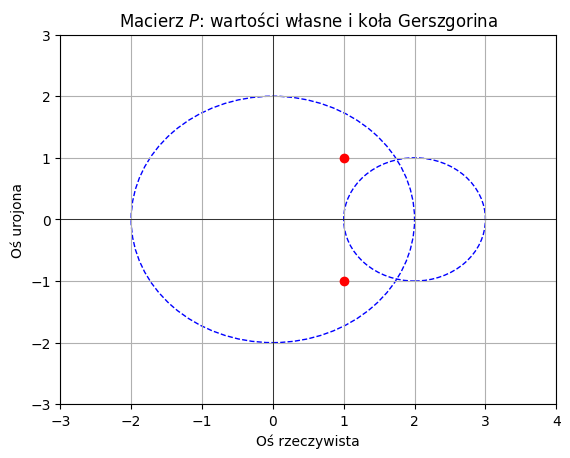

In [11]:
eigenvalues = np.array([1+1j, 1-1j])
circle_centers = np.array([2, 0])
circle_radii = np.array([1, 2])

# Tworzumy wykres
fig, ax = plt.subplots()

# Zaznaczamy wartości własne
ax.plot(eigenvalues.real, eigenvalues.imag, 'ro')

# Zaznaczamy brzegi kół Gerszgorina
for center, radius in zip(circle_centers, circle_radii):
    circle = plt.Circle((center.real, center.imag), radius, color='blue', fill=False, linestyle='--')
    ax.add_artist(circle)

# Rysujemy wykres
ax.axhline(0, color='black',linewidth=0.5)
ax.axvline(0, color='black',linewidth=0.5)
ax.set_xlim(-3, 4)
ax.set_ylim(-3, 3)
plt.grid(True)
plt.title('Macierz $P$: wartości własne i koła Gerszgorina')
plt.xlabel('Oś rzeczywista')
plt.ylabel('Oś urojona')
plt.show()

Jak widać na rysunku, koło $K_2$ zawiera obie wartości własne, zaś koło $K_1$ - ani jednej.

Istnieje jednak twierdzenie, które pozwala dowiedzieć się więcej o lokalizacji wartości własnych w pewnych szczególnych przypadkach.

<hr style="width:30%;">

**Twierdzenie**. *Niech $n$ kół Gerszgorina, $K_{i_1} , \, K_{i_2} , \, \ldots , \, K_{i_n}$, gdzie $n < N$, będzie rozłącznych z każdym z pozostałych $N - n$ kół. Wówczas suma mnogościowa tych kół,*
$$
\bigcup _{k = 1}^n K_{i_k} ,
$$
*zawiera dokładnie $n$ wartości własnych macierzy $M$ (biorąc pod uwagę ich wielokrotności).*

**Wniosek**. *Każde koło Gerszgorina rozłączne z pozostałymi kołami zawiera dokładnie jedną wartość własną macierzy $M$.*

<hr style="width:30%;">

### Zadanie 1. Twierdzenie Gerszgorina: symetryczna macierz rzeczywista.

Rozważmy jednoparametrową rodzinę symetrycznych macierzy rzeczywistych $A (\xi ) \in \mathbb{R}^{3 \times 3}$, gdzie parametr $\xi \in \left[ 0 , \, \infty \right[ $, określonych wzorem
$$
A (\xi ) = \begin{bmatrix}
3 & \xi & \xi \\
\xi & 9 & \xi \\
\xi & \xi & 4
\end{bmatrix} .
$$

1. Napisz funkcję `matrix_A` przyjmującą jako argument liczbę $\xi \in \left[ 0 , \, \infty \right[ $ i zwracającą macierz $A(\xi )$ jako tablicę NumPy.

In [ ]:
def matrix_A(xi: float) -> np.ndarray:
    """Zwraca macierz A(xi) dla danego xi."""

    # Miejsce na Twoje rozwiązanie
    
    return A

Każdy wiersz macierzy $A(\xi )$ zawiera dwa elementy pozadiagonalne, oba równe $\xi $, zatem promienie $R_i$ dla wszystkich wierszy mają taką samą wartość:
$$
R_1 = R_2 = R_3 = 2 \xi . 
$$
Koła Gerszgorina są przedziałami (mamy bowiem do czynienia z symetrycznymi macierzami rzeczywistymi) i mają następującą postać:
\begin{align*}
K_1 &= \bar{K} \left( A_{11}, \, R_1 \right) = \bar{K} \left( 3, \, 2 \xi \right) = \left[ 3 - 2 \xi , \, 3 + 2 \xi \right] , \\
K_2 &= \bar{K} \left( A_{22}, \, R_2 \right) = \bar{K} \left( 9, \, 2 \xi \right) = \left[ 9 - 2 \xi , \, 9 + 2 \xi \right] , \\
K_3 &= \bar{K} \left( A_{33}, \, R_3 \right) = \bar{K} \left( 4, \, 2 \xi \right) = \left[ 4 - 2 \xi , \, 4 + 2 \xi \right] .
\end{align*}

W trywialnym przypadku $\xi = 0$ otrzymujemy macierz diagonalną:
$$
A (0) = \begin{bmatrix}
3 & 0 & 0 \\
0 & 9 & 0 \\
0 & 0 & 4
\end{bmatrix} .
$$
Jej wartości własne, $\lambda _k$, $k = 1, \, 2, \, 3$, to elementy leżące na diagonali. Koła Gerszgorina dla $\xi = 0$ redukują się do rozłącznych zbiorów jednoelementowych, zawierających wyłącznie po jednej wartości własnej:
\begin{align*}
\lambda _1 = 3 & \in \{ 3 \} = [3 , \, 3] = K_1 , \\
\lambda _2 = 9 & \in \{ 9 \} = [9 , \, 9] = K_2 , \\
\lambda _3 = 4 & \in \{ 4 \} = [4 , \, 4] = K_3 .
\end{align*}

Możemy przypuszczać, że dla $\xi \approx 0$ wartości i wektory własne macierzy $A(\xi )$ będą się tylko nieznacznie różniły od wartości i wektorów własnych macierzy $A(0)$. Sprawdźmy, czy rzeczywiście tak jest.

2. Lista `xis` zawiera przykładowe, niewielkie wartości parametru $\xi $. Napisz kod, który dla każdej z nich wyznaczy i wypisze wartości własne, wektory własne oraz koła Gerszgorina macierzy $A(\xi )$. Jak wpływa zwiększanie parametru $\xi $ na wartości własne macierzy $A(\xi )$ i ich położenie wewnątrz kół Gerszgorina?

In [ ]:
xis = [0, 0.01, 0.05, 0.1, 0.15, 0.2, 0.25]

for xi in xis:
    # Miejsce na Twoje rozwiązanie

Gdy $\xi < \frac{1}{4}$, koła Gerszgorina są rozłączne, zatem każde zawiera dokładnie jedną wartość własną; gdy zaś $\frac{1}{4} \leq \xi < \frac{5}{4}$, koła $K_1$ i $K_3$ mają niepuste przecięcie, jednak koło $K_2$ pozostaje rozłączne, spodziewamy się zatem, że $K_2$ zawiera jedną wartość własną, zaś $K_1 \cup K_3$ – dwie.

3. Napisz kod, który przygotuje wykres wartości własnych i kół Gerszgorina w zależności od wartości parametru $\xi $. Na osi poziomej odłóż $\xi $. Wykres powinien przedstawiać:

   * trzy krzywe prezentujące zależność każdej z trzech wartości własnych macierzy $A(\xi )$ od $\xi $,

   * trzy pasma odpowiadające kołom (a właściwie przedziałom) Gerszgorina; wykorzystaj funkcję `fill_between` - przykład jej użycia znajdziesz [tutaj](https://matplotlib.org/stable/plot_types/basic/fill_between.html); dla czytelności warto dodać przezroczystość w sposób opisany [tutaj](https://matplotlib.org/stable/gallery/lines_bars_and_markers/fill_between_alpha.html).

   Twój wykres powinien wizualnie przypominać wykres *random walkers empirical $\mu$ and $\pm \sigma$ interval* z [tej strony](https://matplotlib.org/stable/gallery/lines_bars_and_markers/fill_between_alpha.html) (ale z trzema krzywymi i trzema pasmami).

In [ ]:
# Miejsce na Twoje rozwiązanie

### Zadanie 2. Twierdzenie Gerszgorina: ogólna macierz.

Rozważmy jednoparametrową rodzinę macierzy $B (\xi ) \in \mathbb{R}^{3 \times 3}$, gdzie parametr $\xi \in \left[ 0 , \, \infty \right[ $, określonych wzorem
$$
B (\xi ) = \begin{bmatrix}
1 & -2 \xi & 3 \xi \\
0 & 6 & \xi \\
3 \xi & 0 & 9 + 10 \mathrm{i}
\end{bmatrix} .
$$

1. Napisz funkcję `matrix_B` przyjmującą jako argument liczbę $\xi \in \left[ 0 , \, \infty \right[ $ i zwracającą macierz $B(\xi )$ jako tablicę NumPy.

In [ ]:
def matrix_B(xi: float) -> np.ndarray:
    """Zwraca macierz B(xi) dla danego xi."""

    # Miejsce na Twoje rozwiązanie
    
    return B

2. Wyznacz koła Gerszgorina macierzy $B(\xi )$ dla dowolnego $\xi $.

3. Napisz kod, który zaznaczy na wykresie wartości własne i koła Gerszgorina macierzy $B(1)$. Upewnij się, że rysunek jest zgodny z terazami podanych wyżej twierdzeń.

In [ ]:
# Miejsce na Twoje rozwiązanie

4. W poprzednim punkcie zauważyliśmy, że jedno z kół Gerszgorina jest rozłączne z pozostałymi, zawiera zatem jedną wartość własną. Dla jakiej wartości parametru $\xi $ koło to przestaje być rozłączne? Narysuj analogiczny wykres dla tej wartości $\xi $ oraz dla kilku większych wartości i sprawdź, czy wartość własna, wcześniej zlokalizowana w tym kole, w końcu je opuści.

In [ ]:
# Miejsce na Twoje rozwiązanie

5. *DLA CHĘTNYCH* Stwórz interaktywny wykres, w którym możliwa będzie zmiana wartości parametru $\xi $ za pomocą suwaka.

In [ ]:
# Miejsce na Twoje rozwiązanie

---

## Metoda potęgowa

### Zadanie 3. Metoda potęgowa.

Rozważmy macierz
$$
M = \begin{bmatrix}
2 & 1 & 2 \\
1 & 3 & 2 \\
2 & 2 & 1
\end{bmatrix} .
$$

1. Wykorzystując właściwe funkcje SciPy, znajdź jej wartości i wektory własne.

In [ ]:
# Miejsce na Twoje rozwiązanie

2. Znajdź największą wartość własną macierzy $M$, posługując się metodą potęgową.

In [ ]:
# Miejsce na Twoje rozwiązanie

3. Znajdź najmniejszą wartość własną macierzy $M$, posługując się odwrotną metodą potęgową.

In [ ]:
# Miejsce na Twoje rozwiązanie

4. Znajdź trzecią, pośrednią wartość własną macierzy $M$, posługując się odwrotną metodą potęgową z przesunięciem. Dobierz odpowiednio parametr $\mu $.

In [ ]:
# Miejsce na Twoje rozwiązanie

5. Zastosuj metodę RQI do znalezienia wszystkich trzech wartości własnych macierzy $M$.

Poniższa funkcja generuje symetryczną macierz rzeczywistą rzędu $N$.

In [ ]:
def symmetric_matrix(N : int) -> np.ndarray:
    """Generuje symetryczną macierz rzeczywistą N x N."""

    np.random.seed(0)
    M = np.random.randn(N, N)
    A = (M + M.T) / 2

    return A

6. Napisz funkcję, która znajduje największą wartość własną takiej macierzy za pomocą metody RQI dla dowolnego $N$.

---

## Metoda QR

### Zadanie 4. Metoda QR.

Rozważmy macierz
$$
M = \begin{bmatrix}
2 & 1 & 2 \\
1 & 3 & 2 \\
2 & 2 & 1
\end{bmatrix} .
$$

1. Posługując się odpowiednimi funkcjami SciPy, znajdź jej rozkład QR.

In [ ]:
# Miejsce na Twoje rozwiązanie

2. Upewnij się, że macierze $Q$ i $R$ mają wymagane własności.

In [ ]:
# Miejsce na Twoje rozwiązanie

3. Napisz kod, który odczyta z macierzy $R$ wartości własne macierzy $M$.

In [ ]:
# Miejsce na Twoje rozwiązanie

4. Używając odpowiednich funkcji SciPy, znajdź wartości i wektory własne macierzy $M$. Czy wyniki zgadzają się z tymi, które uzyskałeś wyżej?

In [ ]:
# Miejsce na Twoje rozwiązanie

---

## Praca domowa

### Zadanie 5. Algorytm PageRank.
*Pojawi się niebawem.*